# NovaPay - Fraudulent Transaction Detection for Digital Money Transfer

## Day 4 - Feature Engineering & Exploratory Data Analysis

Fraud patterns often hide in behaviour rather than in a single transaction record. This notebook builds time-based, behavioural, geographic, device, velocity, and historical-risk features, then uses exploratory analysis to compare fraudulent and legitimate transactions.

**Objectives**

- Generate predictive features from the cleaned Day 3 dataset.
- Aggregate per-customer metrics such as transaction frequency, value, and recency.
- Create transfer corridor, time-of-day, weekday, device, and risk-context features.
- Visualize how engineered features differ between fraud and non-fraud cases.
- Save the feature-enhanced dataset for later modelling.

This notebook intentionally does **not** include model training, train-test splitting, SMOTE, threshold tuning, or model evaluation.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.4f}".format)


## 2. Load Cleaned Dataset

The Day 4 workflow starts from the cleaned Day 3 dataset: `data/processed/cleaned_transactions.csv`.


In [2]:
DATA_PATH = Path("data/processed/cleaned_transactions.csv")
FEATURE_OUTPUT_PATH = Path("data/processed/feature_engineered_transactions.csv")
FIGURE_DIR = Path("reports/figures/day4")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found at {DATA_PATH}. "
        "Run Day 3 first or place cleaned_transactions.csv in data/processed/."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from: {DATA_PATH}")


Loaded dataset from: data\processed\cleaned_transactions.csv


### Initial Dataset Checks


In [3]:
print("Shape:", df.shape)
display(df.head())


Shape: (10940, 26)


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.1900,278.1900,4.2500,1.3514,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.1230,standard,263,0.5220,0,0.2230,0,0,0.0000,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.5100,154.2900,4.2400,12.7586,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.5690,standard,947,0.4750,0,0.2680,0,1,0.0000,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.3300,160.3300,2.7000,7.1429,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.4370,enhanced,367,0.9390,0,0.1760,0,0,0.0000,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.4100,59.4100,2.2200,0.9259,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.5940,standard,147,0.5510,0,0.3910,0,0,0.0000,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.9600,200.9600,3.6100,83.3333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.1210,enhanced,257,0.8940,0,0.2570,0,0,0.0000,0


In [4]:
print("Column names:")
for column in df.columns:
    print("-", column)


Column names:
- transaction_id
- customer_id
- timestamp
- home_country
- source_currency
- dest_currency
- channel
- amount_src
- amount_usd
- fee
- exchange_rate_src_to_dest
- device_id
- new_device
- ip_address
- ip_country
- location_mismatch
- ip_risk_score
- kyc_tier
- account_age_days
- device_trust_score
- chargeback_history_count
- risk_score_internal
- txn_velocity_1h
- txn_velocity_24h
- corridor_risk
- is_fraud


In [5]:
print("Data types:")
display(df.dtypes)


Data types:


transaction_id                object
customer_id                   object
timestamp                     object
home_country                  object
source_currency               object
dest_currency                 object
channel                       object
amount_src                   float64
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                     object
new_device                      bool
ip_address                    object
ip_country                    object
location_mismatch               bool
ip_risk_score                float64
kyc_tier                      object
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
dtype: object

In [6]:
print("Fraud label distribution:")
display(df["is_fraud"].value_counts(dropna=False).rename("count").to_frame())

print("\nFraud label distribution (%):")
display((df["is_fraud"].value_counts(normalize=True, dropna=False) * 100).round(2).rename("percent").to_frame())


Fraud label distribution:


,count
is_fraud,
0,9951
1,989



Fraud label distribution (%):


,percent
is_fraud,
0,90.9600
1,9.0400


## 3. Validate Required Columns

The notebook checks that the expected Day 3 columns are present before feature engineering begins. This prevents silent errors later in the workflow.


In [7]:
required_columns = [
    "transaction_id",
    "customer_id",
    "timestamp",
    "home_country",
    "dest_currency",
    "channel",
    "amount_usd",
    "device_id",
    "new_device",
    "ip_country",
    "location_mismatch",
    "ip_risk_score",
    "kyc_tier",
    "account_age_days",
    "device_trust_score",
    "chargeback_history_count",
    "risk_score_internal",
    "txn_velocity_1h",
    "txn_velocity_24h",
    "corridor_risk",
    "is_fraud",
]

missing_required = [column for column in required_columns if column not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("All required columns are present.")


All required columns are present.


## 4. Convert Timestamp

Timestamps are converted to UTC so time-based features are consistent across transactions.


In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)

invalid_timestamps = df["timestamp"].isna().sum()
print(f"Invalid or missing timestamps after conversion: {invalid_timestamps}")

if invalid_timestamps > 0:
    display(df.loc[df["timestamp"].isna(), ["transaction_id", "timestamp"]].head())


Invalid or missing timestamps after conversion: 0


## 5. Feature Engineering


### A. Time-Based Features

These features capture when transactions happen. Fraud can cluster during unusual hours or days when monitoring, customer support, or customer behaviour differs from normal patterns.


In [9]:
original_columns = set(df.columns)

df["transaction_hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.weekday
df["weekday_name"] = df["timestamp"].dt.day_name()
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)
df["is_night_transaction"] = df["transaction_hour"].between(0, 5).astype(int)

display(df[["timestamp", "transaction_hour", "weekday", "weekday_name", "is_weekend", "is_night_transaction"]].head())


,timestamp,transaction_hour,weekday,weekday_name,is_weekend,is_night_transaction
0,2022-10-03 18:40:59.468549+00:00,18,0,Monday,0,0
1,2022-10-03 20:39:38.468549+00:00,20,0,Monday,0,0
2,2022-10-03 23:02:43.468549+00:00,23,0,Monday,0,0
3,2022-10-04 01:08:53.468549+00:00,1,1,Tuesday,0,1
4,2022-10-04 09:35:03.468549+00:00,9,1,Tuesday,0,0


### B. Geographic and Corridor Features

Corridor and mismatch features capture location context. These can be useful for fraud detection, but they should be reviewed carefully because geographic patterns may also reflect legitimate customer populations.


In [10]:
df["country_mismatch_flag"] = (
    df["home_country"].astype(str).str.upper()
    != df["ip_country"].astype(str).str.upper()
).astype(int)

df["corridor"] = (
    df["home_country"].astype(str).str.strip()
    + "_to_"
    + df["dest_currency"].astype(str).str.strip()
)

df["corridor_risk_band"] = pd.cut(
    df["corridor_risk"],
    bins=[-np.inf, 0.2, 0.4, 0.6, 0.8, np.inf],
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
)

display(df[["home_country", "ip_country", "dest_currency", "country_mismatch_flag", "corridor", "corridor_risk", "corridor_risk_band"]].head())


,home_country,ip_country,dest_currency,country_mismatch_flag,corridor,corridor_risk,corridor_risk_band
0,US,US,CAD,0,US_to_CAD,0.0000,Very Low
1,CA,CA,MXN,0,CA_to_MXN,0.0000,Very Low
2,US,US,CNY,0,US_to_CNY,0.0000,Very Low
3,US,US,EUR,0,US_to_EUR,0.0000,Very Low
4,US,US,INR,0,US_to_INR,0.0000,Very Low


### C. Customer Behaviour Features

Customer-level aggregations help identify transactions that differ from a customer's usual behaviour. This is often more useful than looking only at the raw transaction amount.


In [11]:
customer_agg = (
    df.groupby("customer_id")
    .agg(
        customer_transaction_count=("transaction_id", "count"),
        customer_total_amount=("amount_usd", "sum"),
        customer_avg_amount=("amount_usd", "mean"),
        customer_max_amount=("amount_usd", "max"),
        customer_amount_std=("amount_usd", "std"),
        customer_first_txn=("timestamp", "min"),
        customer_last_txn=("timestamp", "max"),
    )
    .reset_index()
)

df = df.merge(customer_agg, on="customer_id", how="left")
df["customer_amount_std"] = df["customer_amount_std"].fillna(0)
df["amount_to_customer_avg"] = df["amount_usd"] / df["customer_avg_amount"].replace(0, np.nan)

latest_timestamp = df["timestamp"].max()
df["customer_recency_days"] = (latest_timestamp - df["customer_last_txn"]).dt.total_seconds() / (60 * 60 * 24)

display(
    df[
        [
            "customer_id",
            "amount_usd",
            "customer_transaction_count",
            "customer_total_amount",
            "customer_avg_amount",
            "customer_max_amount",
            "customer_amount_std",
            "amount_to_customer_avg",
            "customer_first_txn",
            "customer_last_txn",
            "customer_recency_days",
        ]
    ].head()
)


,customer_id,amount_usd,customer_transaction_count,customer_total_amount,customer_avg_amount,customer_max_amount,customer_amount_std,amount_to_customer_avg,customer_first_txn,customer_last_txn,customer_recency_days
0,402cccc9-28de-45b3-9af7-cc5302aa1f93,278.1900,1451,"528,176.3200",374.0625,"9,998.7300","1,304.4855",0.7437,2022-10-03 18:40:59.468549+00:00,2025-11-29 06:03:37.468549+00:00,16.7570
1,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,154.2900,340,"110,461.2700",334.7311,"7,398.8800","1,125.4411",0.4609,2022-10-03 20:39:38.468549+00:00,2025-10-17 04:27:06.468549+00:00,59.8240
2,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,160.3300,1017,"375,113.8100",381.9896,"9,998.7000","1,326.7117",0.4197,2022-10-03 23:02:43.468549+00:00,2025-12-16 00:13:41.468549+00:00,0.0000
3,7bd5200c-5d19-44f0-9afe-8b339a05366b,59.4100,773,"342,533.3400",451.2956,"9,997.7800","1,543.4045",0.1316,2022-10-04 01:08:53.468549+00:00,2025-10-02 08:45:19.468549+00:00,74.6447
4,70a93d26-8e3a-4179-900c-a4a7a74d08e5,200.9600,652,"259,221.2200",406.9407,"9,998.8900","1,398.6432",0.4938,2022-10-04 09:35:03.468549+00:00,2025-11-08 19:35:58.468549+00:00,37.1929


### D. Device Behaviour Features

Device-level features help capture whether a device is repeatedly associated with transactions and whether the device has a strong or weak trust profile.


In [12]:
device_agg = (
    df.groupby("device_id")
    .agg(
        device_transaction_count=("transaction_id", "count"),
        device_avg_trust_score=("device_trust_score", "mean"),
    )
    .reset_index()
)

df = df.merge(device_agg, on="device_id", how="left")

df["device_trust_band"] = pd.cut(
    df["device_trust_score"],
    bins=[-np.inf, 0.2, 0.4, 0.6, 0.8, np.inf],
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
)

display(df[["device_id", "device_transaction_count", "device_trust_score", "device_avg_trust_score", "device_trust_band"]].head())


,device_id,device_transaction_count,device_trust_score,device_avg_trust_score,device_trust_band
0,9f292dcc-3297-4947-a260-6a1ef69041ff,7,0.5220,0.5006,Medium
1,3a95b9f5-309f-4684-a46d-e2ff2435bf78,3,0.4750,0.5750,Medium
2,a4737752-9aac-43ed-9d8b-2ccdffc24052,22,0.9390,0.9322,Very High
3,6aeb85a3-5603-4221-896c-9e6882764f1a,21,0.5510,0.5439,Medium
4,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,34,0.8940,0.8895,Very High


### E. Velocity and Risk Flags

Velocity and risk flags convert continuous risk signals into interpretable indicators. Percentile thresholds are useful for EDA because they highlight the highest-risk tail of the distribution.


In [13]:
velocity_1h_threshold = df["txn_velocity_1h"].quantile(0.95)
velocity_24h_threshold = df["txn_velocity_24h"].quantile(0.95)
ip_risk_threshold = df["ip_risk_score"].quantile(0.95)
device_trust_threshold = df["device_trust_score"].quantile(0.05)

df["high_velocity_1h_flag"] = (df["txn_velocity_1h"] >= velocity_1h_threshold).astype(int)
df["high_velocity_24h_flag"] = (df["txn_velocity_24h"] >= velocity_24h_threshold).astype(int)
df["any_velocity_risk_flag"] = (
    (df["high_velocity_1h_flag"] == 1) | (df["high_velocity_24h_flag"] == 1)
).astype(int)
df["high_ip_risk_flag"] = (df["ip_risk_score"] >= ip_risk_threshold).astype(int)
df["low_device_trust_flag"] = (df["device_trust_score"] <= device_trust_threshold).astype(int)

print("Thresholds used:")
print(f"95th percentile txn_velocity_1h: {velocity_1h_threshold:,.4f}")
print(f"95th percentile txn_velocity_24h: {velocity_24h_threshold:,.4f}")
print(f"95th percentile ip_risk_score: {ip_risk_threshold:,.4f}")
print(f"5th percentile device_trust_score: {device_trust_threshold:,.4f}")

display(
    df[
        [
            "txn_velocity_1h",
            "txn_velocity_24h",
            "ip_risk_score",
            "device_trust_score",
            "high_velocity_1h_flag",
            "high_velocity_24h_flag",
            "any_velocity_risk_flag",
            "high_ip_risk_flag",
            "low_device_trust_flag",
        ]
    ].head()
)


Thresholds used:
95th percentile txn_velocity_1h: 5.0000
95th percentile txn_velocity_24h: 6.0000
95th percentile ip_risk_score: 1.0000
5th percentile device_trust_score: 0.2150


,txn_velocity_1h,txn_velocity_24h,ip_risk_score,device_trust_score,high_velocity_1h_flag,high_velocity_24h_flag,any_velocity_risk_flag,high_ip_risk_flag,low_device_trust_flag
0,0,0,0.1230,0.5220,0,0,0,0,0
1,0,1,0.5690,0.4750,0,0,0,0,0
2,0,0,0.4370,0.9390,0,0,0,0,0
3,0,0,0.5940,0.5510,0,0,0,0,0
4,0,0,0.1210,0.8940,0,0,0,0,0


### F. Chargeback Features

Previous chargebacks are a historical-risk signal. A grouped feature makes this signal easier to compare in EDA plots.


In [14]:
df["chargeback_group"] = np.where(
    df["chargeback_history_count"] > 0,
    "Previous Chargeback",
    "No Chargeback",
)

display(df[["chargeback_history_count", "chargeback_group"]].head())


,chargeback_history_count,chargeback_group
0,0,No Chargeback
1,0,No Chargeback
2,0,No Chargeback
3,0,No Chargeback
4,0,No Chargeback


## 6. Save Feature-Enhanced Dataset


In [15]:
FEATURE_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(FEATURE_OUTPUT_PATH, index=False)
print(f"Feature-enhanced dataset saved to: {FEATURE_OUTPUT_PATH}")


Feature-enhanced dataset saved to: data\processed\feature_engineered_transactions.csv


## 7. EDA Visualisations

The plots below compare fraud and non-fraud patterns across behavioural, time-based, geographic, device, and risk-context features. Each plot is also saved to `reports/figures/day4/`.


In [16]:
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_plot(filename):
    output_path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Saved figure to: {output_path}")


def plot_fraud_rate(data, column, title, filename, top_n=None, min_count=None):
    summary = (
        data.groupby(column, observed=False)
        .agg(count=("is_fraud", "size"), fraud_rate=("is_fraud", "mean"))
        .reset_index()
        .dropna(subset=[column])
    )

    if min_count is not None:
        summary = summary[summary["count"] >= min_count]

    summary = summary.sort_values("fraud_rate", ascending=False)

    if top_n is not None:
        summary = summary.head(top_n)

    if summary.empty:
        print(f"No data available for {column} after filtering.")
        return summary

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=summary, x=column, y="fraud_rate", color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("Fraud rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
    plt.xticks(rotation=35, ha="right")

    for container in ax.containers:
        ax.bar_label(container, labels=[f"{value:.1%}" for value in summary["fraud_rate"]], fontsize=9)

    save_current_plot(filename)
    plt.show()

    display(summary)
    return summary


### Fraud Class Distribution

This chart shows the level of class imbalance in the dataset. Fraud datasets are usually imbalanced, so downstream modelling should avoid relying on accuracy alone.


Saved figure to: reports\figures\day4\fraud_class_distribution.png


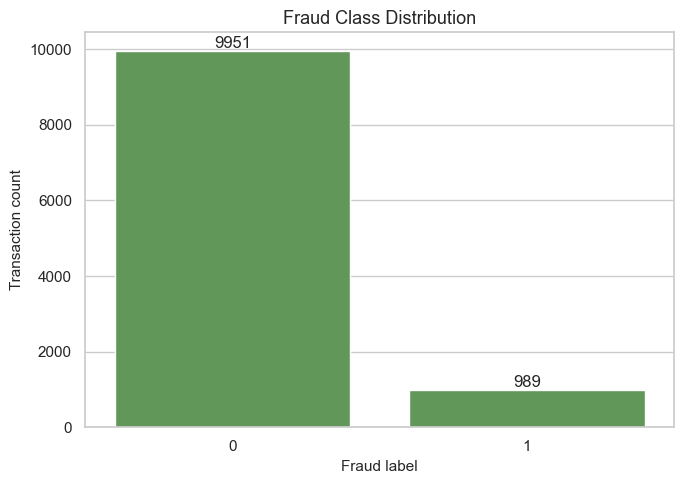

,is_fraud,count
0,0,9951
1,1,989


In [17]:
class_counts = df["is_fraud"].value_counts().sort_index().reset_index()
class_counts.columns = ["is_fraud", "count"]

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=class_counts, x="is_fraud", y="count", color="#59A14F")
ax.set_title("Fraud Class Distribution")
ax.set_xlabel("Fraud label")
ax.set_ylabel("Transaction count")
ax.bar_label(ax.containers[0], fmt="%.0f")
save_current_plot("fraud_class_distribution.png")
plt.show()

display(class_counts)


### Fraud Rate by Channel

Channel-level differences may reveal higher-risk transaction paths. Interpret cautiously because channel risk may reflect customer mix, product design, or monitoring rules.


Saved figure to: reports\figures\day4\fraud_rate_by_channel.png


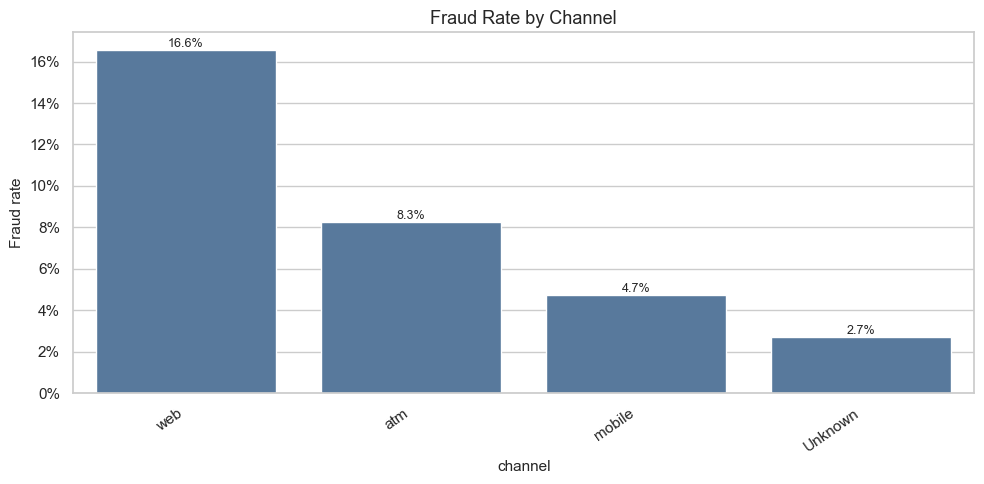

,channel,count,fraud_rate
3,web,3685,0.1658
1,atm,978,0.0828
2,mobile,6240,0.0474
0,Unknown,37,0.0270


In [18]:
channel_summary = plot_fraud_rate(df, "channel", "Fraud Rate by Channel", "fraud_rate_by_channel.png")


### Fraud Rate by Home Country

Country-level patterns can indicate risky routes or operational differences. This feature needs careful fairness review because geography can become a proxy for protected or sensitive attributes.


Saved figure to: reports\figures\day4\fraud_rate_by_home_country.png


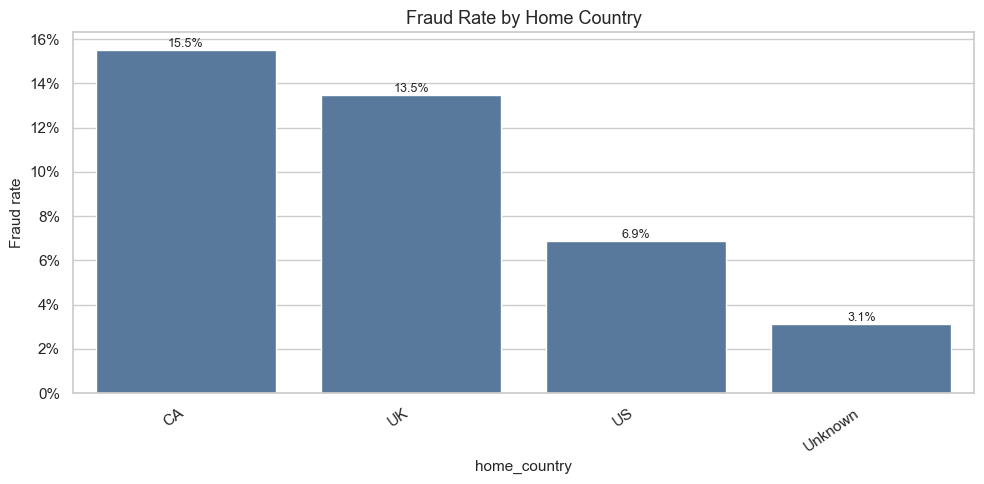

,home_country,count,fraud_rate
0,CA,1185,0.1553
1,UK,2047,0.1348
2,US,7676,0.0688
3,Unknown,32,0.0312


In [19]:
home_country_summary = plot_fraud_rate(df, "home_country", "Fraud Rate by Home Country", "fraud_rate_by_home_country.png", top_n=15)


### Fraud Rate by KYC Tier

KYC tier may separate customer risk levels because stronger verification can reduce fraud opportunity. It should be interpreted with care because KYC availability and completion can differ across customer groups.


Saved figure to: reports\figures\day4\fraud_rate_by_kyc_tier.png


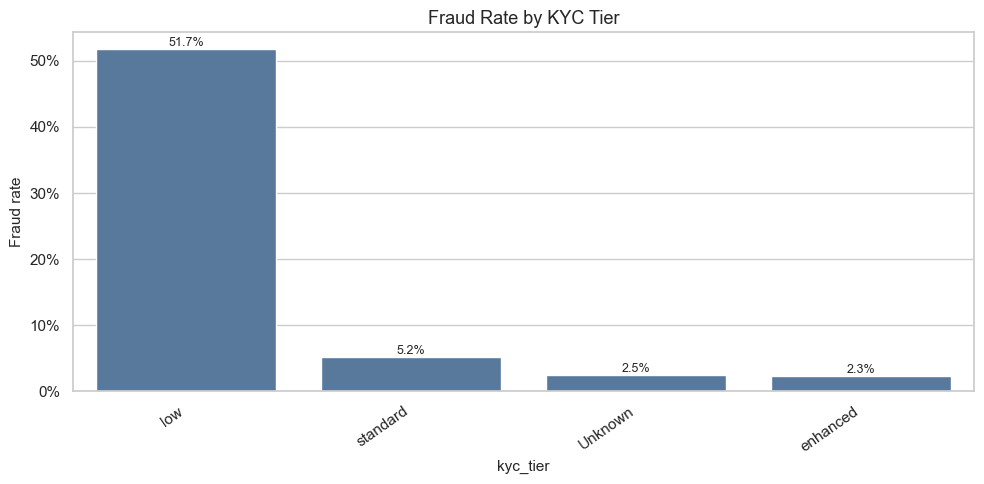

,kyc_tier,count,fraud_rate
2,low,1034,0.5174
3,standard,7786,0.0520
0,Unknown,318,0.0252
1,enhanced,1802,0.0228


In [20]:
kyc_summary = plot_fraud_rate(df, "kyc_tier", "Fraud Rate by KYC Tier", "fraud_rate_by_kyc_tier.png")


### Fraud Rate by New Device

New device use can be a strong behavioural signal. A higher fraud rate for new devices may suggest account takeover or first-use abuse, but legitimate customers also change devices.


Saved figure to: reports\figures\day4\fraud_rate_by_new_device.png


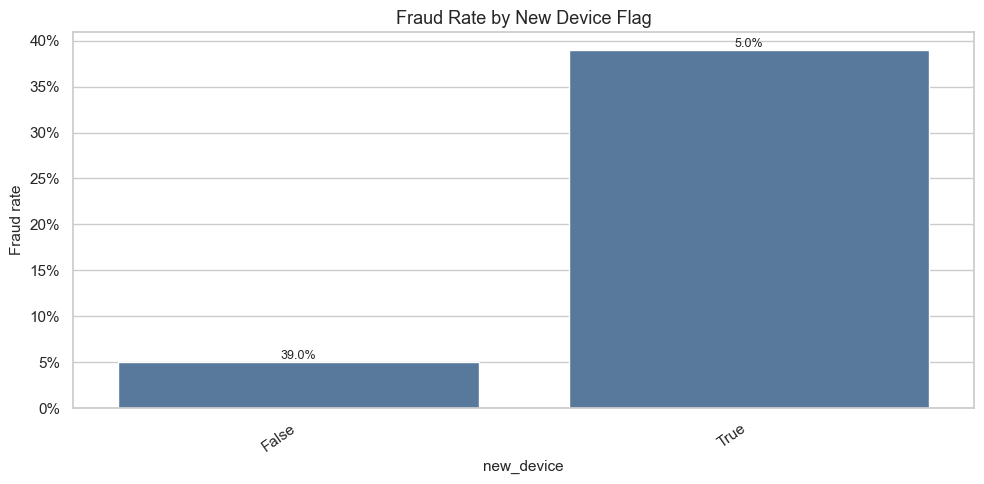

,new_device,count,fraud_rate
1,True,1309,0.3896
0,False,9631,0.0497


In [21]:
new_device_summary = plot_fraud_rate(df, "new_device", "Fraud Rate by New Device Flag", "fraud_rate_by_new_device.png")


### Fraud Rate by Location Mismatch

Location mismatch compares the account's home country with IP location information. It may indicate suspicious access, although legitimate travel and VPN usage can also produce mismatches.


Saved figure to: reports\figures\day4\fraud_rate_by_location_mismatch.png


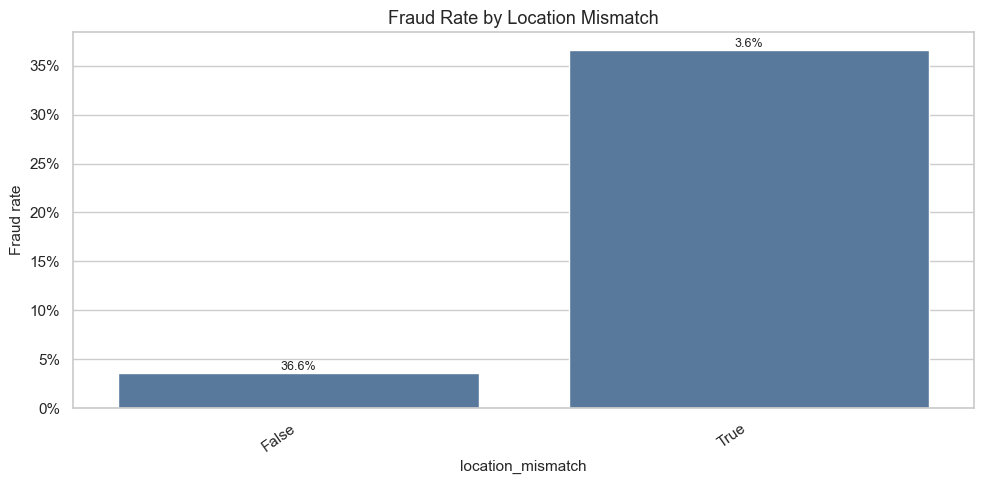

,location_mismatch,count,fraud_rate
1,True,1796,0.3658
0,False,9144,0.0363


In [22]:
location_mismatch_summary = plot_fraud_rate(df, "location_mismatch", "Fraud Rate by Location Mismatch", "fraud_rate_by_location_mismatch.png")


### Fraud Rate by Chargeback History

Chargeback history captures historical risk. It can be useful because past disputes may be associated with future risk, but labels should be checked for errors or customer-service edge cases.


Saved figure to: reports\figures\day4\fraud_rate_by_chargeback_group.png


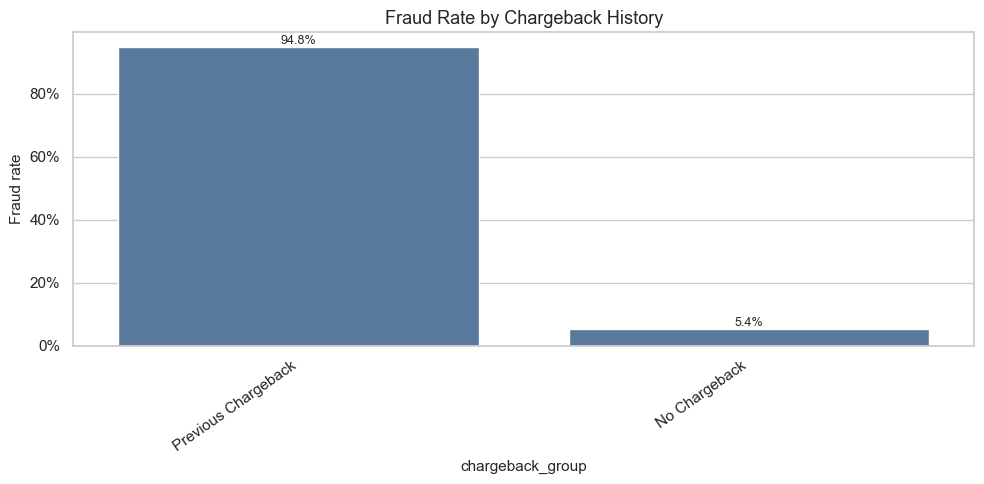

,chargeback_group,count,fraud_rate
1,Previous Chargeback,440,0.9477
0,No Chargeback,10500,0.0545


In [23]:
chargeback_summary = plot_fraud_rate(df, "chargeback_group", "Fraud Rate by Chargeback History", "fraud_rate_by_chargeback_group.png")


### Fraud Rate by Device Trust Band

Device trust band groups device risk into interpretable levels. Low trust can be useful for fraud detection, but the trust score itself should be audited for how it was produced.


Saved figure to: reports\figures\day4\fraud_rate_by_device_trust_band.png


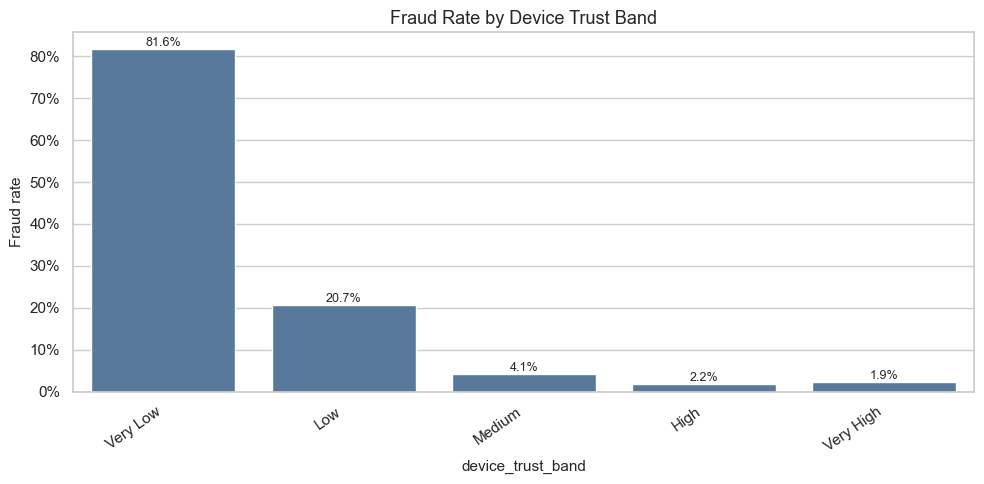

,device_trust_band,count,fraud_rate
0,Very Low,501,0.8164
1,Low,1644,0.2068
2,Medium,2563,0.0414
4,Very High,4730,0.0220
3,High,1212,0.0190


In [24]:
device_trust_band_summary = plot_fraud_rate(df, "device_trust_band", "Fraud Rate by Device Trust Band", "fraud_rate_by_device_trust_band.png")


### Fraud Rate by Corridor Risk Band

Corridor risk band summarizes transfer-route risk. Higher-risk bands may be useful, but route-level features need monitoring to avoid unfairly penalizing legitimate corridors.


In [26]:
def plot_fraud_rate(data, column, title, filename, top_n=None, min_count=None):
    summary = (
        data.groupby(column, observed=True)["is_fraud"]
        .agg(count="count", fraud_rate="mean")
        .reset_index()
        .sort_values("fraud_rate", ascending=False)
    )

    if min_count is not None:
        summary = summary[summary["count"] >= min_count]

    if top_n is not None:
        summary = summary.head(top_n)

    plt.figure(figsize=(9, 4))
    ax = sns.barplot(
        data=summary,
        x=column,
        y="fraud_rate",
        errorbar=None
    )

    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Fraud Rate")
    plt.xticks(rotation=35, ha="right")

    for i, row in summary.reset_index(drop=True).iterrows():
        ax.text(
            i,
            row["fraud_rate"],
            f"{row['fraud_rate']:.1%}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    save_current_plot(filename)
    plt.show()

    return summary

Saved figure to: reports\figures\day4\fraud_rate_by_corridor_risk_band.png


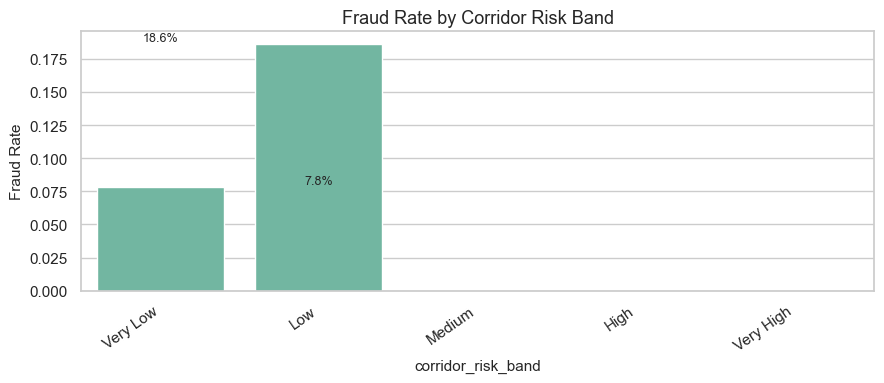

In [27]:
corridor_risk_band_summary = plot_fraud_rate(df, "corridor_risk_band", "Fraud Rate by Corridor Risk Band", "fraud_rate_by_corridor_risk_band.png")


### Fraud Rate by Night Transaction Flag

Night transactions may behave differently from daytime transactions. If fraud is concentrated at night, this feature can help detect unusual timing patterns.


Saved figure to: reports\figures\day4\fraud_rate_by_night_transaction.png


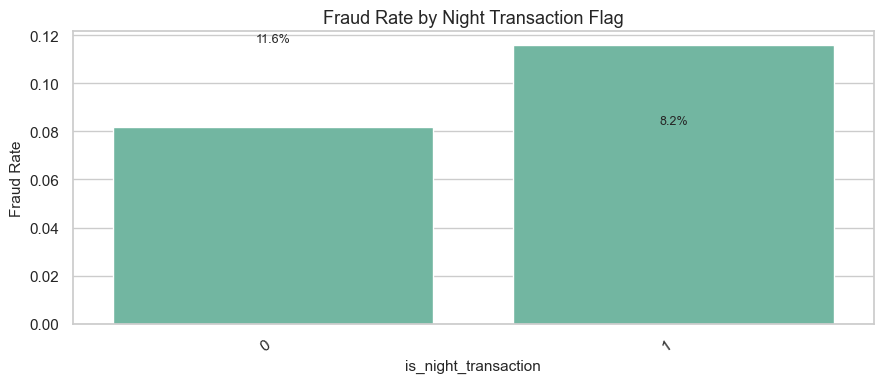

In [28]:
night_summary = plot_fraud_rate(df, "is_night_transaction", "Fraud Rate by Night Transaction Flag", "fraud_rate_by_night_transaction.png")


### Fraud Rate by Weekend Flag

Weekend patterns can differ from weekday patterns because customer routines and operational monitoring may change. Any difference should be checked against transaction volume.


Saved figure to: reports\figures\day4\fraud_rate_by_weekend.png


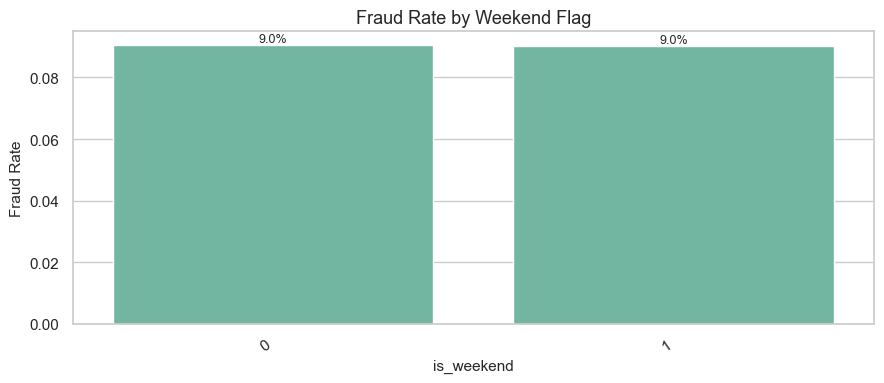

In [29]:
weekend_summary = plot_fraud_rate(df, "is_weekend", "Fraud Rate by Weekend Flag", "fraud_rate_by_weekend.png")


### Amount Distribution by Fraud Class

This chart compares transaction amount distributions. Amount can be useful, especially when combined with customer history, but fraud may not always involve unusually large transactions.


Saved figure to: reports\figures\day4\amount_distribution_by_fraud_class.png


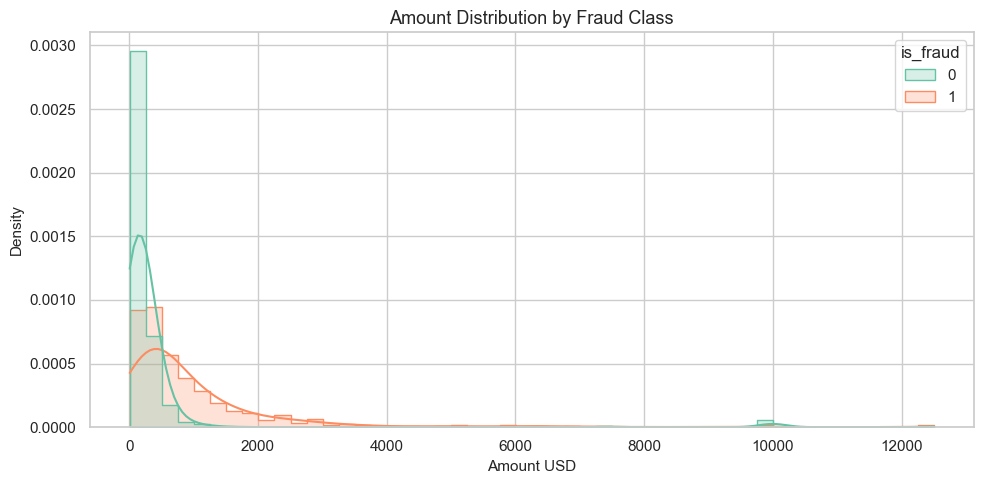

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="amount_usd",
    hue="is_fraud",
    bins=50,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
)
plt.title("Amount Distribution by Fraud Class")
plt.xlabel("Amount USD")
plt.ylabel("Density")
save_current_plot("amount_distribution_by_fraud_class.png")
plt.show()


### IP Risk Score Distribution by Fraud Class

IP risk score is a risk-context feature. Separation between the fraud and non-fraud curves would suggest that network context helps distinguish suspicious activity.


Saved figure to: reports\figures\day4\ip_risk_score_distribution_by_fraud_class.png


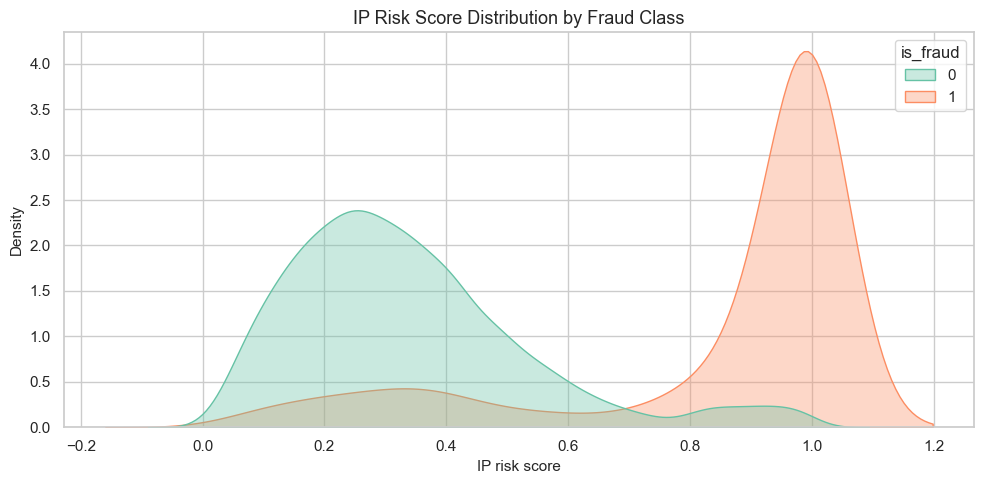

In [31]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="ip_risk_score", hue="is_fraud", common_norm=False, fill=True, alpha=0.35)
plt.title("IP Risk Score Distribution by Fraud Class")
plt.xlabel("IP risk score")
plt.ylabel("Density")
save_current_plot("ip_risk_score_distribution_by_fraud_class.png")
plt.show()


### Device Trust Score Distribution by Fraud Class

Device trust score can separate safer known-device behaviour from suspicious device behaviour. A lower trust distribution for fraud would make this feature especially useful.


Saved figure to: reports\figures\day4\device_trust_score_distribution_by_fraud_class.png


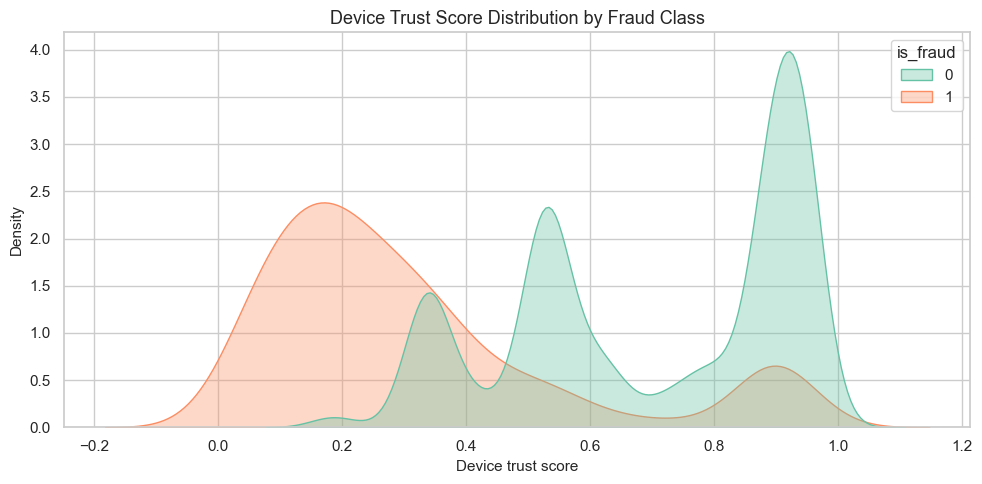

In [32]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="device_trust_score", hue="is_fraud", common_norm=False, fill=True, alpha=0.35)
plt.title("Device Trust Score Distribution by Fraud Class")
plt.xlabel("Device trust score")
plt.ylabel("Density")
save_current_plot("device_trust_score_distribution_by_fraud_class.png")
plt.show()


### Correlation Heatmap of Numeric Features

Correlation helps identify relationships between numerical features and fraud, but it does not prove causation. It can also miss non-linear patterns and interactions.


Saved figure to: reports\figures\day4\numeric_feature_correlation_heatmap.png


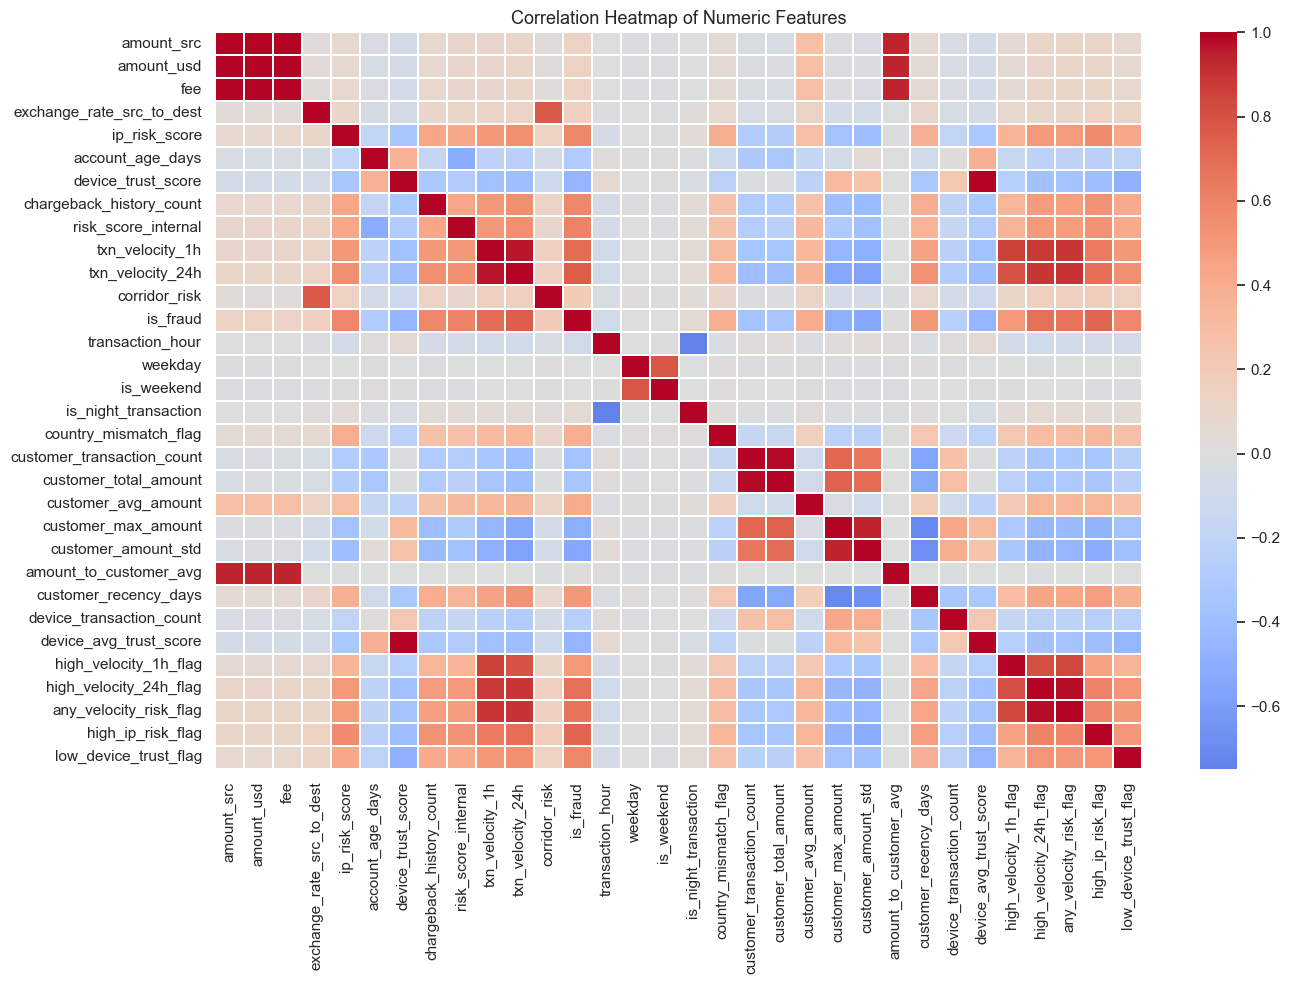

,correlation_with_is_fraud
txn_velocity_24h,0.7556
high_ip_risk_flag,0.7289
txn_velocity_1h,0.6945
high_velocity_24h_flag,0.6823
any_velocity_risk_flag,0.6676
risk_score_internal,0.6075
ip_risk_score,0.5870
chargeback_history_count,0.5828
low_device_trust_flag,0.5825
customer_amount_std,-0.5372


In [33]:
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap of Numeric Features")
save_current_plot("numeric_feature_correlation_heatmap.png")
plt.show()

if "is_fraud" in correlation.columns:
    fraud_correlations = (
        correlation["is_fraud"]
        .drop("is_fraud", errors="ignore")
        .sort_values(key=lambda values: values.abs(), ascending=False)
        .head(15)
        .rename("correlation_with_is_fraud")
        .to_frame()
    )
    display(fraud_correlations)


### Top 10 Corridors by Transaction Count

High-volume corridors help explain where most activity occurs. They are not automatically the riskiest corridors, but they are important for monitoring because they affect many customers.


Saved figure to: reports\figures\day4\top_10_corridors_by_transaction_count.png


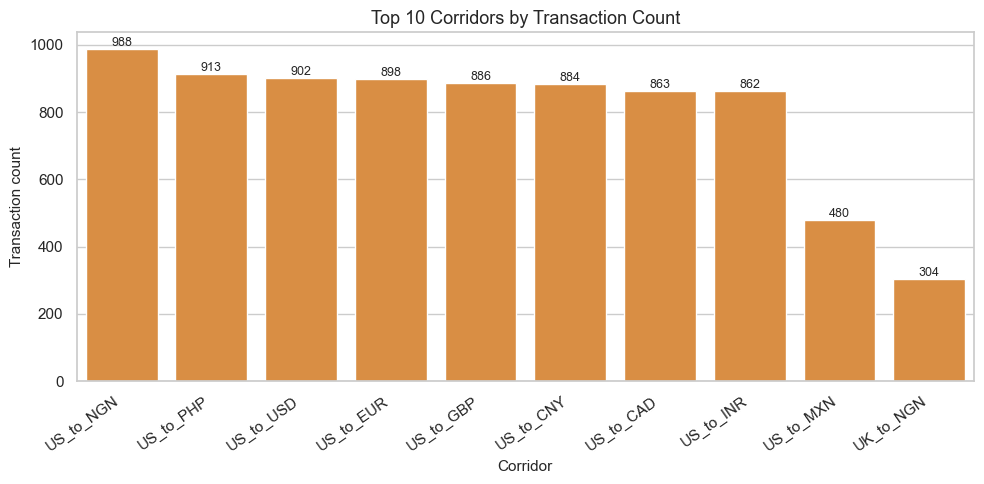

,corridor,transaction_count
0,US_to_NGN,988
1,US_to_PHP,913
2,US_to_USD,902
3,US_to_EUR,898
4,US_to_GBP,886
5,US_to_CNY,884
6,US_to_CAD,863
7,US_to_INR,862
8,US_to_MXN,480
9,UK_to_NGN,304


In [34]:
top_corridors_count = df["corridor"].value_counts().head(10).reset_index()
top_corridors_count.columns = ["corridor", "transaction_count"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=top_corridors_count, x="corridor", y="transaction_count", color="#F28E2B")
ax.set_title("Top 10 Corridors by Transaction Count")
ax.set_xlabel("Corridor")
ax.set_ylabel("Transaction count")
plt.xticks(rotation=35, ha="right")
ax.bar_label(ax.containers[0], fmt="%.0f", fontsize=9)
save_current_plot("top_10_corridors_by_transaction_count.png")
plt.show()

display(top_corridors_count)


### Top 10 Corridors by Fraud Rate

This view filters to corridors with at least 20 transactions to reduce unstable rates from tiny groups. Even with this filter, corridor fraud rates should be interpreted alongside volume and business context.


Saved figure to: reports\figures\day4\top_10_corridors_by_fraud_rate_min_20.png


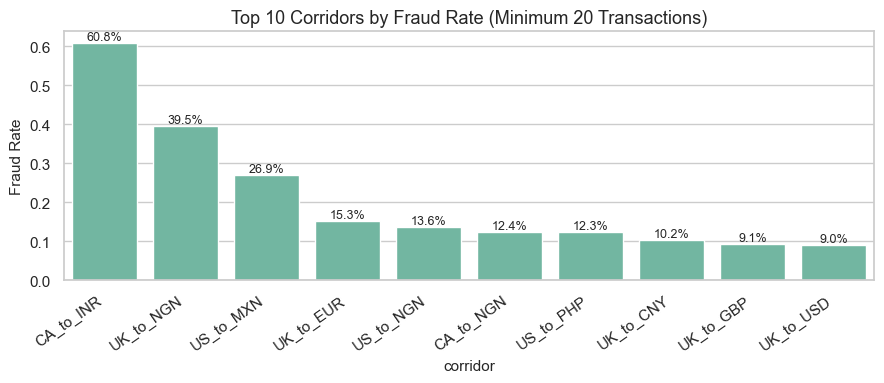

In [35]:
top_corridors_fraud_rate = plot_fraud_rate(
    df,
    "corridor",
    "Top 10 Corridors by Fraud Rate (Minimum 20 Transactions)",
    "top_10_corridors_by_fraud_rate_min_20.png",
    top_n=10,
    min_count=20,
)


## 8. Feature Summary Table


In [36]:
feature_summary = pd.DataFrame(
    [
        ("transaction_hour", "Time-based", "Captures hour-of-day timing patterns."),
        ("is_weekend", "Time-based", "Identifies weekend behaviour that may differ from weekdays."),
        ("is_night_transaction", "Time-based", "Flags transactions during late-night hours."),
        ("corridor", "Geographic/corridor", "Represents the transfer route from home country to destination currency."),
        ("country_mismatch_flag", "Geographic/corridor", "Flags disagreement between home country and IP country."),
        ("customer_transaction_count", "Customer behaviour", "Measures customer activity frequency."),
        ("amount_to_customer_avg", "Customer behaviour", "Compares transaction size with the customer's normal amount."),
        ("device_transaction_count", "Device behaviour", "Measures how often a device appears in the dataset."),
        ("high_velocity_1h_flag", "Velocity/risk", "Flags unusually high short-term transaction velocity."),
        ("high_velocity_24h_flag", "Velocity/risk", "Flags unusually high daily transaction velocity."),
        ("device_trust_band", "Device behaviour", "Groups device trust into interpretable risk bands."),
        ("chargeback_group", "Historical risk", "Separates customers with and without previous chargebacks."),
        ("corridor_risk_band", "Geographic/corridor", "Groups corridor risk into interpretable bands."),
    ],
    columns=["feature_name", "feature_type", "reason_useful"],
)

display(feature_summary)


,feature_name,feature_type,reason_useful
0,transaction_hour,Time-based,Captures hour-of-day timing patterns.
1,is_weekend,Time-based,Identifies weekend behaviour that may differ f...
2,is_night_transaction,Time-based,Flags transactions during late-night hours.
3,corridor,Geographic/corridor,Represents the transfer route from home countr...
4,country_mismatch_flag,Geographic/corridor,Flags disagreement between home country and IP...
5,customer_transaction_count,Customer behaviour,Measures customer activity frequency.
6,amount_to_customer_avg,Customer behaviour,Compares transaction size with the customer's ...
7,device_transaction_count,Device behaviour,Measures how often a device appears in the dat...
8,high_velocity_1h_flag,Velocity/risk,Flags unusually high short-term transaction ve...
9,high_velocity_24h_flag,Velocity/risk,Flags unusually high daily transaction velocity.


## 9. Reflection

**Which features most clearly separate fraudulent from legitimate transactions?**

Behavioural and risk-context features most clearly separate fraud from non-fraud. The strongest signals include chargeback history, location mismatch, low device trust, new device use, high transaction velocity, KYC tier, IP risk score, and corridor risk. These features capture behaviour and risk context rather than only the transaction amount, making them more useful for identifying fraud patterns.

However, some features such as geography and KYC tier should be used carefully because they may introduce bias. These features should be monitored for fairness, reviewed with business context, and tested for whether they create harmful outcomes for legitimate customers.


## 10. Assessment Quiz

**Q1. Which feature types are often most useful in fraud detection?**

Answer: Behavioural, velocity, device, geographic, and historical-risk features.

**Q2. Why should EDA plots be interpreted carefully?**

Answer: EDA plots show associations, not causation, and may be affected by class imbalance, sample size, or bias in historical labels.


## 11. Final Quality Checks


In [37]:
engineered_features = sorted(set(df.columns) - original_columns)

print("Final shape:", df.shape)
print("Number of engineered features added:", len(engineered_features))
print("\nEngineered features:")
for feature in engineered_features:
    print("-", feature)

print("\nMissing values summary:")
missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0].to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())
print(f"Fraud rate: {df['is_fraud'].mean():.2%}")
print(f"Saved output path: {FEATURE_OUTPUT_PATH}")


Final shape: (10940, 52)
Number of engineered features added: 26

Engineered features:
- amount_to_customer_avg
- any_velocity_risk_flag
- chargeback_group
- corridor
- corridor_risk_band
- country_mismatch_flag
- customer_amount_std
- customer_avg_amount
- customer_first_txn
- customer_last_txn
- customer_max_amount
- customer_recency_days
- customer_total_amount
- customer_transaction_count
- device_avg_trust_score
- device_transaction_count
- device_trust_band
- high_ip_risk_flag
- high_velocity_1h_flag
- high_velocity_24h_flag
- is_night_transaction
- is_weekend
- low_device_trust_flag
- transaction_hour
- weekday
- weekday_name

Missing values summary:


,missing_count
amount_to_customer_avg,290
device_trust_band,290
amount_usd,290
fee,290
ip_address,290
device_trust_score,290
device_avg_trust_score,2
customer_avg_amount,2
customer_max_amount,2



Duplicate rows: 0
Fraud rate: 9.04%
Saved output path: data\processed\feature_engineered_transactions.csv


## 12. Conclusion

This notebook generated behavioural, time-based, geographic, device, velocity, and chargeback features and used EDA to compare fraud and non-fraud patterns. The resulting feature-enhanced dataset is ready for later modelling.
